In [1]:
from pathlib import Path
import sys
import json
from torch_geometric.loader import DataLoader
from evaluation_functions import *

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from shared.meshgraphnet_functions import *

In [2]:
#choose the model to test and the dataset to test it on

dataset_name = "example_dataset"
model_name = "example_model"
split_to_test = "test"

In [3]:
with open(rf"C:\PBF-MeshGraphNet\models\{model_name}\model_config.json", "r") as f:
    config = json.load(f)

latent_size = config["latent_size"]
num_processor_blocks = config["num_processor_blocks"]
training_dataset = config["training_dataset"]


model_path = rf"C:\PBF-MeshGraphNet\models\{model_name}\{model_name}.pt"
history_path = rf"C:\PBF-MeshGraphNet\models\{model_name}\{model_name}_loss_history.csv"
normalization_path = rf"C:\PBF-MeshGraphNet\models\{model_name}\{model_name}_normalization.json"

test_path = rf"C:\PBF-MeshGraphNet\datasets\{dataset_name}\{split_to_test}"
train_path = rf"C:\PBF-MeshGraphNet\datasets\{training_dataset}\train"
metadata_path = rf"C:\PBF-MeshGraphNet\datasets\{dataset_name}\dataset_metadata.csv"
external_path = rf"C:\PBF-MeshGraphNet\datasets\external_samples\external_samples"

In [4]:
with open(normalization_path, 'r') as f:
    normalization_data = json.load(f)
    feature_mean = normalization_data['feature_mean']
    feature_std = normalization_data['feature_std']
    continuous_feature_columns = normalization_data['continuous_feature_columns']

test_dataset = MeshDataset(test_path, feature_mean, feature_std, continuous_feature_columns)
input_size = test_dataset.num_features

checkpoint = torch.load(model_path, map_location = "cpu")
model = MeshGraphNet(latent_size = latent_size, node_input_size = input_size, num_processor_blocks = num_processor_blocks)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_loader = DataLoader(test_dataset, shuffle = False, batch_size = 1)

if Path(metadata_path).exists():
    metadata_df = pd.read_csv(metadata_path, index_col = "sample_name")
else:
    metadata_df = None


In [5]:
evaluate_split(model, test_loader, metadata_df)

['cone_010']:  
MSE = 9.0279 | RMSE = 3.0047 | MAE = 2.4904 | Max Error = 14.2304 | Mean Percent Error = 2.4507% 
Abaqus solve time = 701.72 seconds | MeshGraphNet prediction time = 9.74 seconds | Prediction speedup = 98.61% 

['cone_011']:  
MSE = 8.1121 | RMSE = 2.8482 | MAE = 2.0493 | Max Error = 8.0845 | Mean Percent Error = 1.9415% 
Abaqus solve time = 128.78 seconds | MeshGraphNet prediction time = 3.99 seconds | Prediction speedup = 96.90% 

['cuboid_010']:  
MSE = 35.9110 | RMSE = 5.9926 | MAE = 4.9734 | Max Error = 35.6984 | Mean Percent Error = 2.5047% 
Abaqus solve time = 251.37 seconds | MeshGraphNet prediction time = 5.79 seconds | Prediction speedup = 97.70% 

['cuboid_011']:  
MSE = 47.9125 | RMSE = 6.9219 | MAE = 5.6800 | Max Error = 28.9612 | Mean Percent Error = 3.2592% 
Abaqus solve time = 72.45 seconds | MeshGraphNet prediction time = 3.76 seconds | Prediction speedup = 94.81% 

['cylinder_010']:  
MSE = 4.9378 | RMSE = 2.2221 | MAE = 1.6889 | Max Error = 14.1784 | 

Model MSE:         350.4984
Mean baseline MSE: 4522.3350
Target std:        66.6586
Prediction std:    67.1787
Correlation:       0.9622


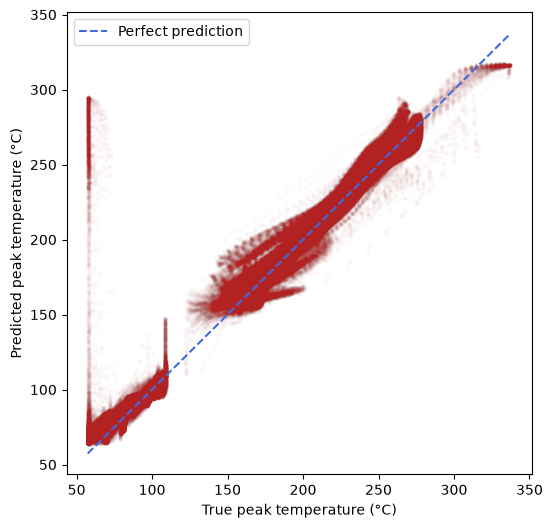

Plot MSE: 350.49844
Plot RMSE: 18.721603
VAL
target min/max/mean/std: 57.382545471191406 337.42071533203125 145.12301635742188 66.6585464477539
pred min/max/mean/std: 63.54600143432617 317.5600891113281 148.54251098632812 67.17866516113281


In [6]:
train_dataset = MeshDataset(train_path, feature_mean, feature_std, continuous_feature_columns)

training_mean = calculate_dataset_target_mean(train_dataset)

targets, predictions = evaluate_model_and_mean_baseline(
    model=model,
    dataset=test_dataset,
    device="cpu",
    training_mean=training_mean,
)

plot_model_prediction_vs_target(targets, predictions)

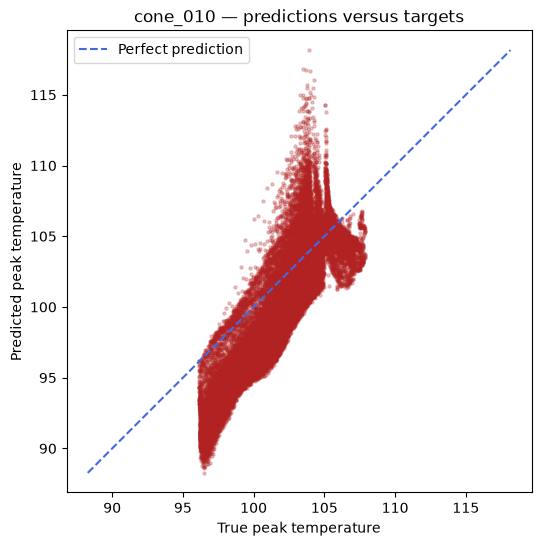

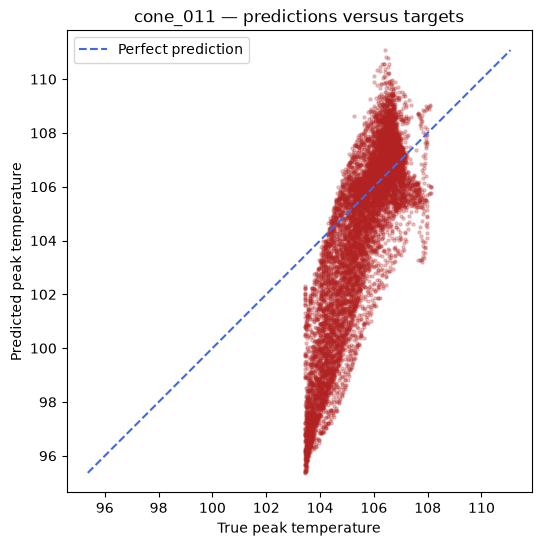

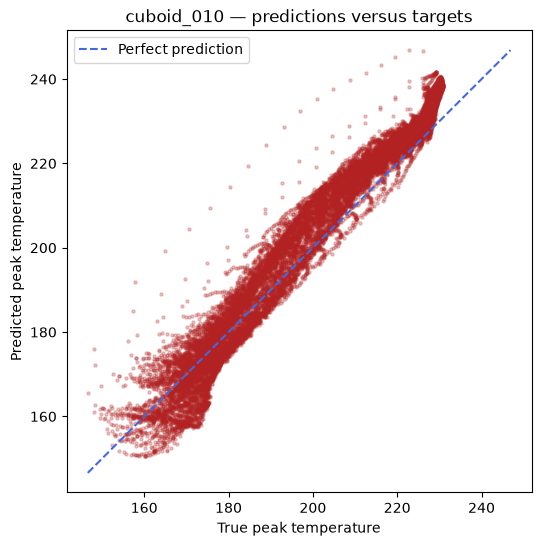

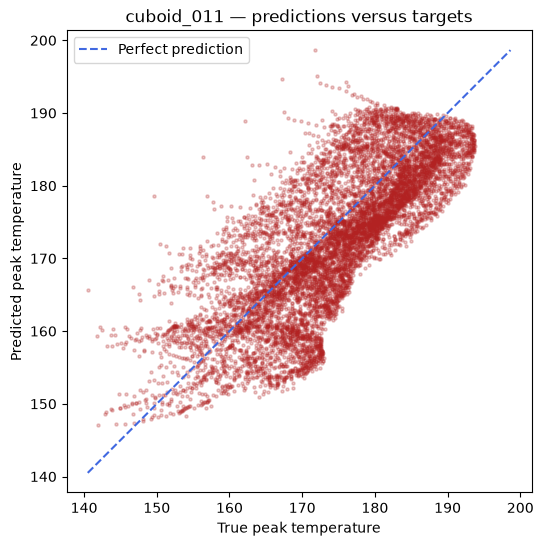

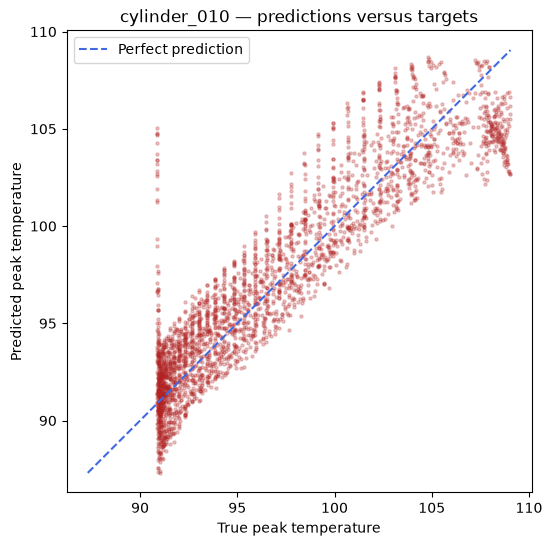

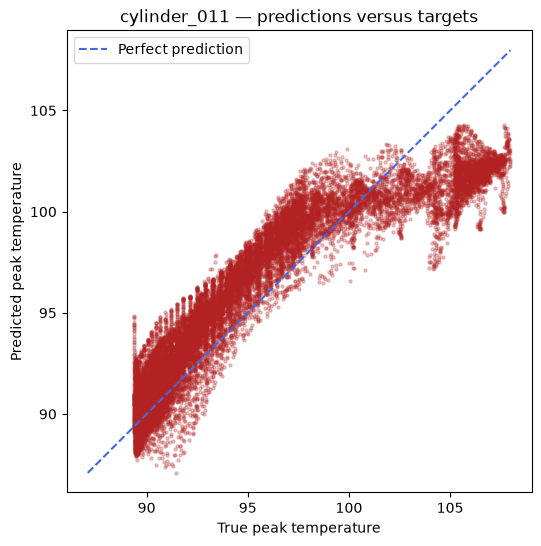

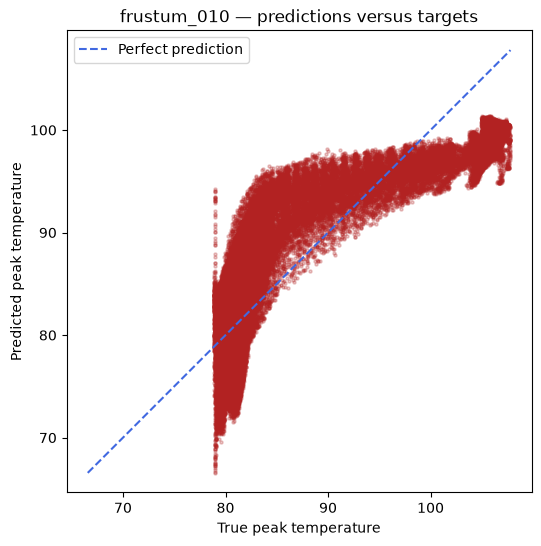

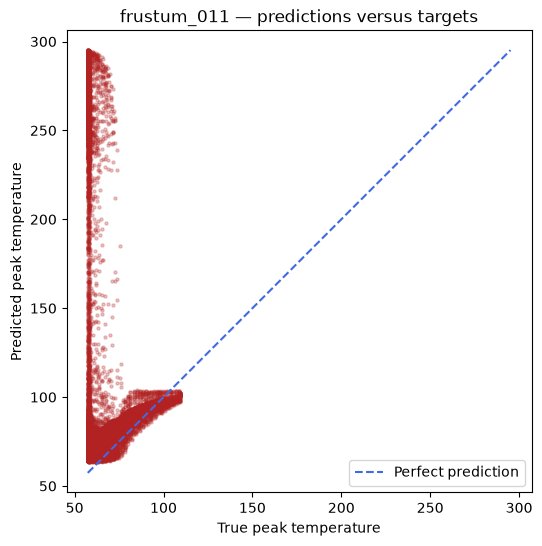

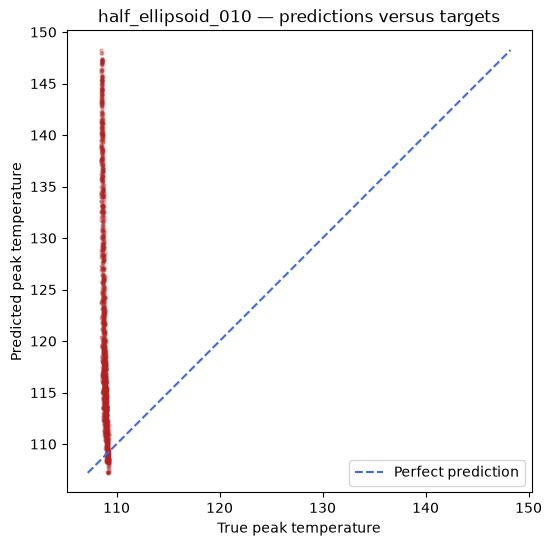

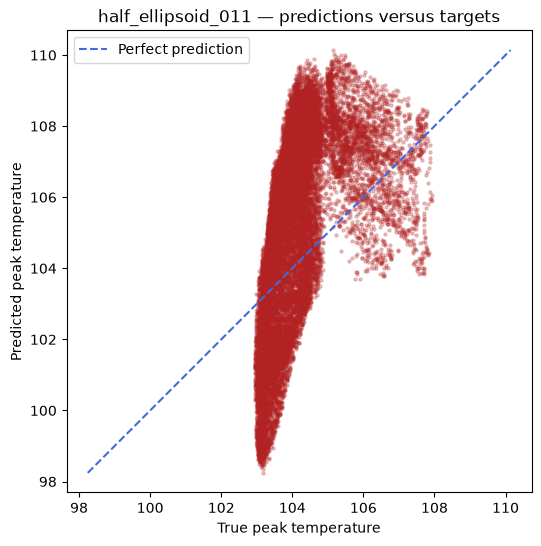

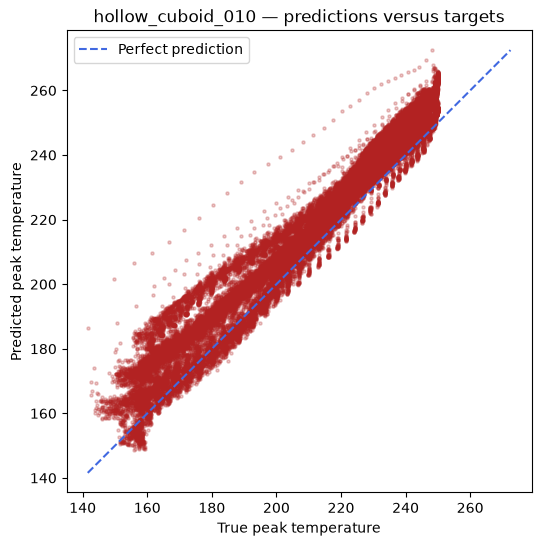

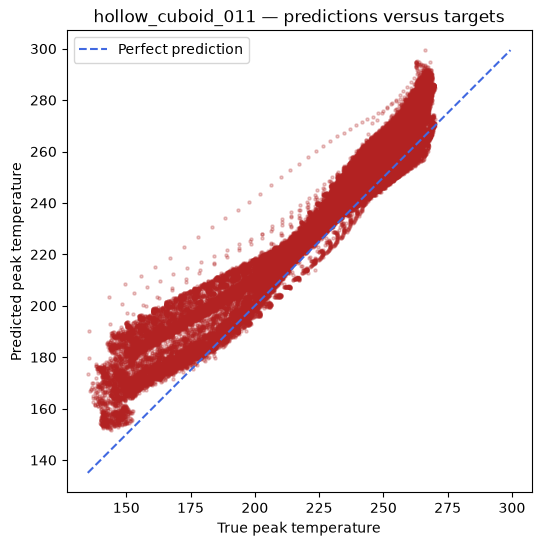

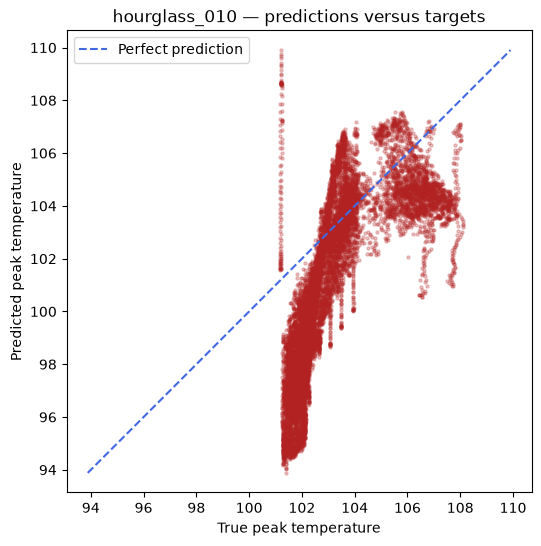

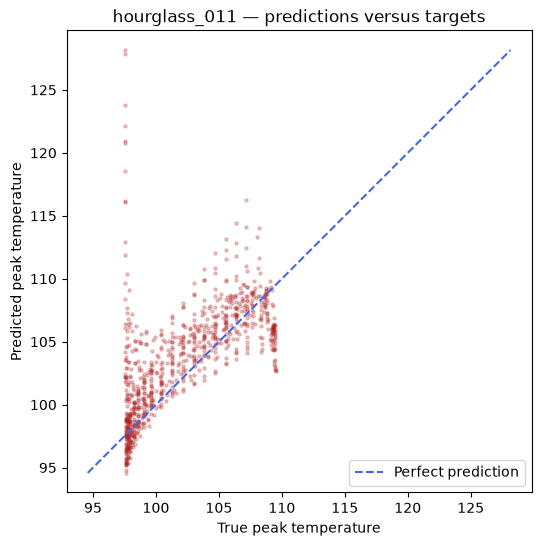

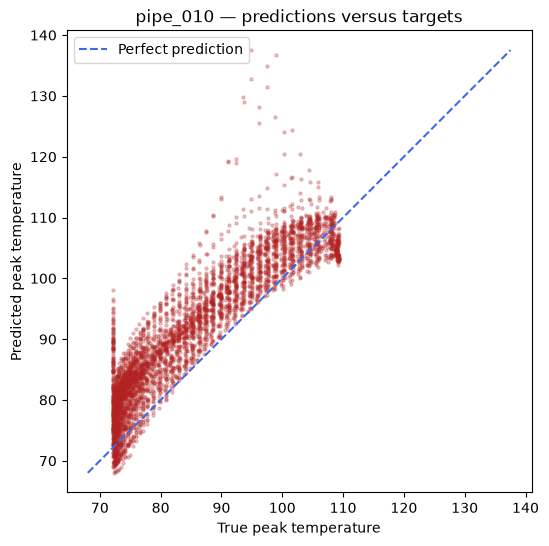

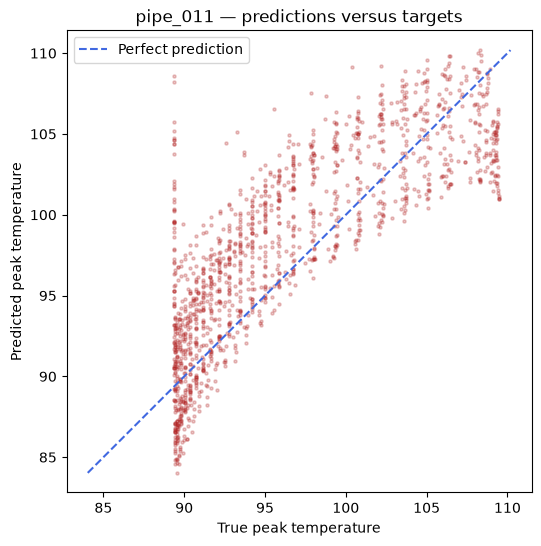

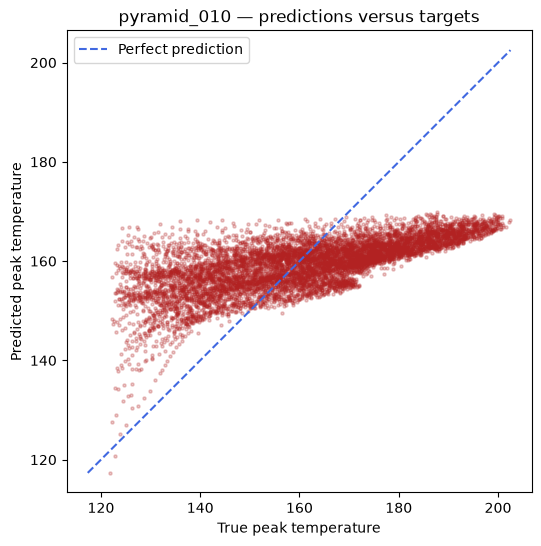

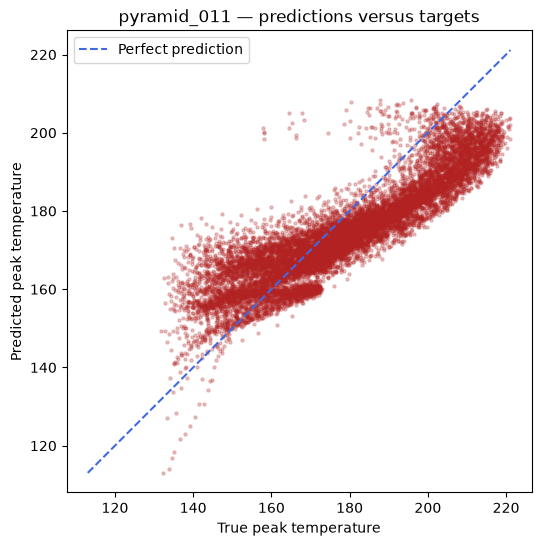

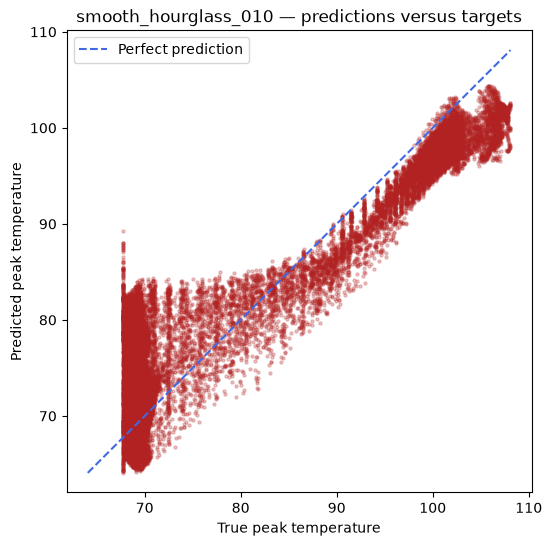

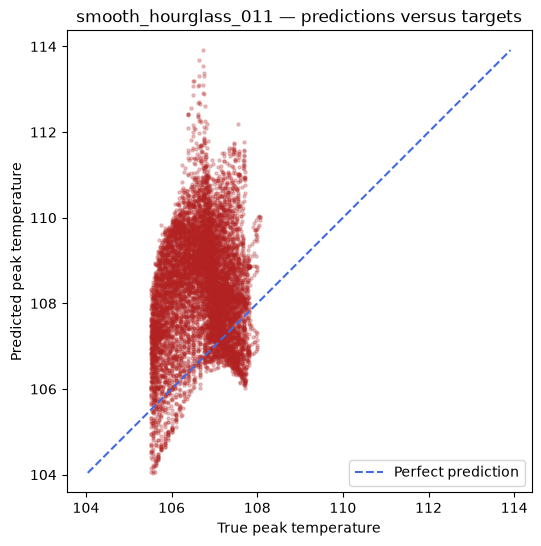

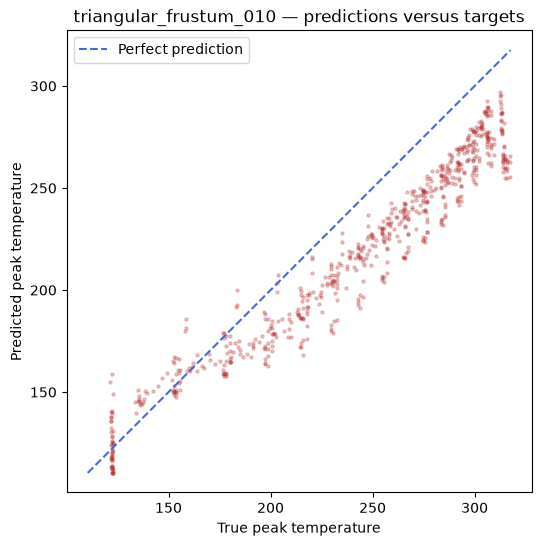

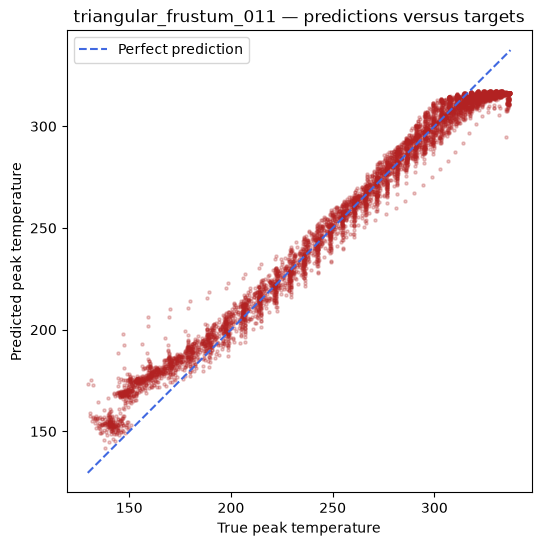

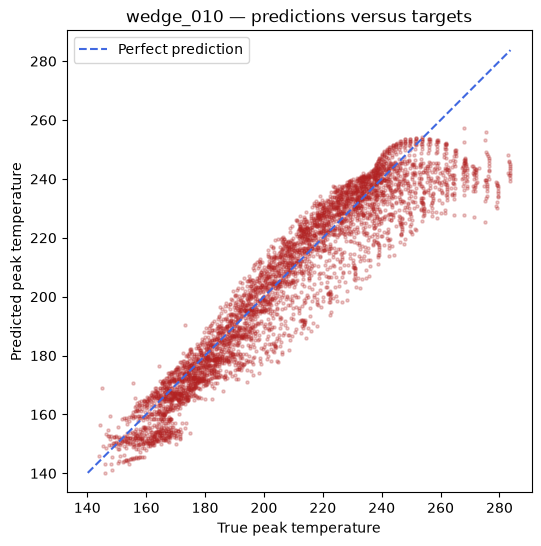

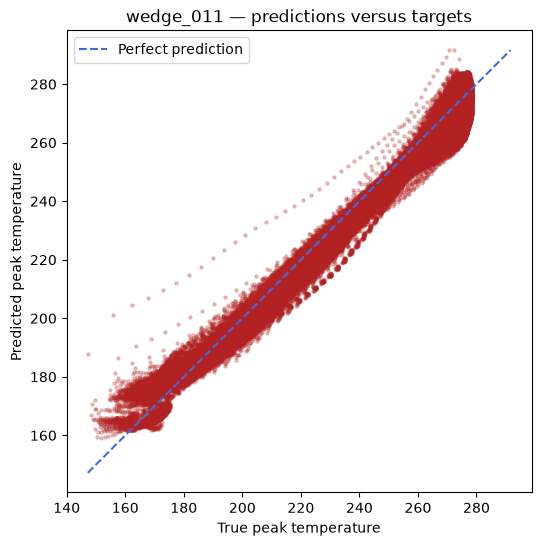

In [7]:
plot_each_test_graph(model, test_dataset, "cpu")